### Architecture
In this experiment swin tranformer model is taken and applied on images with final head removal and single pawpularity output is added. In addition, strong resolution with strong augmentation is added, and MSELoss is added 

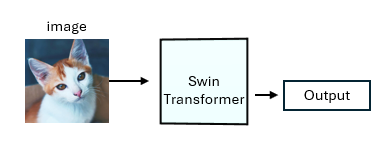

### Analysis
Swin models see the image as a set of tokens and uses multi‑head self‑attention to capture long‑range dependencies and global layout (how the pet, background, and other objects relate across the whole frame), whereas EfficientNet relies on local convolutions and pooling, which are less expressive for scene‑level images 


In [15]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

main_folder = "../.."
sys.path.insert(0, os.path.join(main_folder))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [3]:
from src.config import EXP_CONFIGS
from src.swin_cam import (
    cam_for_single_fold,
    show_cam_triplet,
    ensemble_cam_across_folds,
    plot_ensemble_result,
)

In [4]:
cfg = EXP_CONFIGS["exp3"].copy()
cfg["img_size"] = 384
cfg["loss"] = "mse"
cfg["name"] = "exp3_swin_384_strong_MSE"

img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "extra", "exp3_swin_384_strong_MSE")

backbone_name = cfg["backbone"]
img_size = cfg["img_size"]

df = pd.read_csv(os.path.join(main_folder, "data", "train.csv"))
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))

print(df.shape)
print(oof_df.shape)

(9912, 14)
(9912, 5)


In [5]:
fold = 1

fold_sub = oof_df[oof_df["fold"] == fold].copy()
fold_sub = fold_sub.sort_values("abs_err", ascending=False)
fold_sub.head()

,Id,fold,ytrue,oof_pred,abs_err
730,12b136b947a64c8b23e3929f70b41933,1,100,26.959175,73.040825
3703,5ec5ae4a559fa603f4878376b81c6e50,1,100,29.695250,70.304750
1183,1e59bc4bf0f630df8f17fb908b7c13c2,1,100,33.752468,66.247532
1740,2c4e3ff2fce74d3db4dfb2cc625dd91e,1,100,34.267921,65.732079
6156,9f40aa2a4e04c42f3e3b6e76070f2dea,1,100,36.444668,63.555332


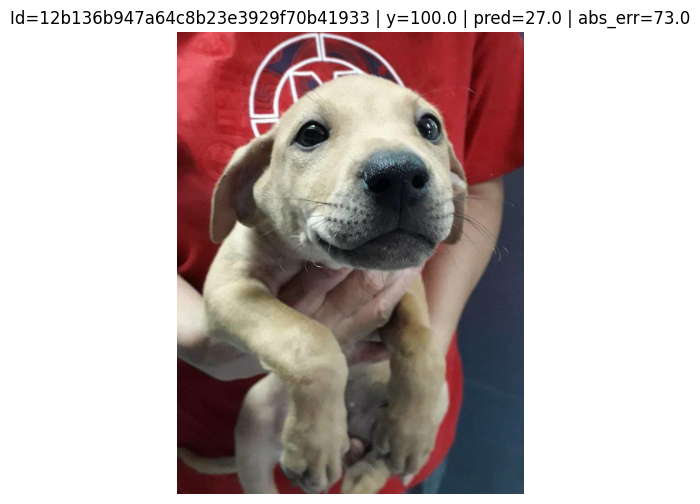

In [6]:
row = fold_sub.iloc[0]
img_id = row["Id"]

img_path = os.path.join(img_folder, img_id + ".jpg")
img_pil = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img_pil)
plt.title(f"Id={img_id} | y={row['ytrue']:.1f} | pred={row['oof_pred']:.1f} | abs_err={row['abs_err']:.1f}")
plt.axis("off")
plt.show()

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


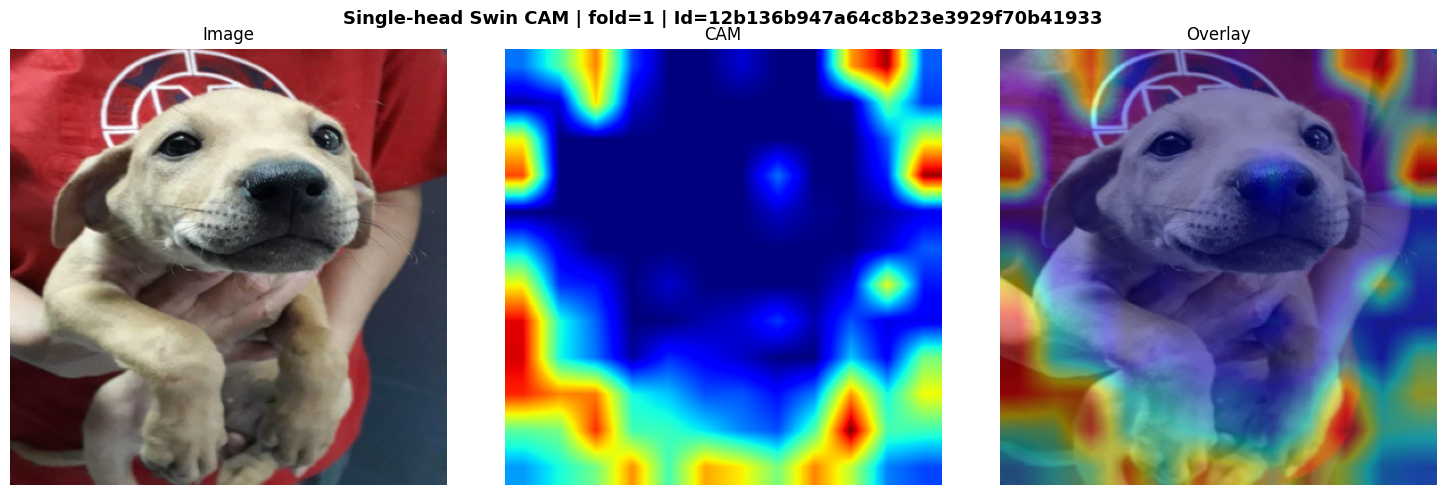

In [7]:
ckpt_path = os.path.join(out_dir, f"model_fold{fold}.pt")
cam, input_tensor, model = cam_for_single_fold(
    img_pil=img_pil,
    ckpt_path=ckpt_path,
    backbone_name=backbone_name,
    img_size=img_size,
    device=device,
)

fig = show_cam_triplet(
    input_tensor=input_tensor,
    cam=cam,
    title=f"Single-head Swin CAM | fold={fold} | Id={img_id}",
)
plt.show()

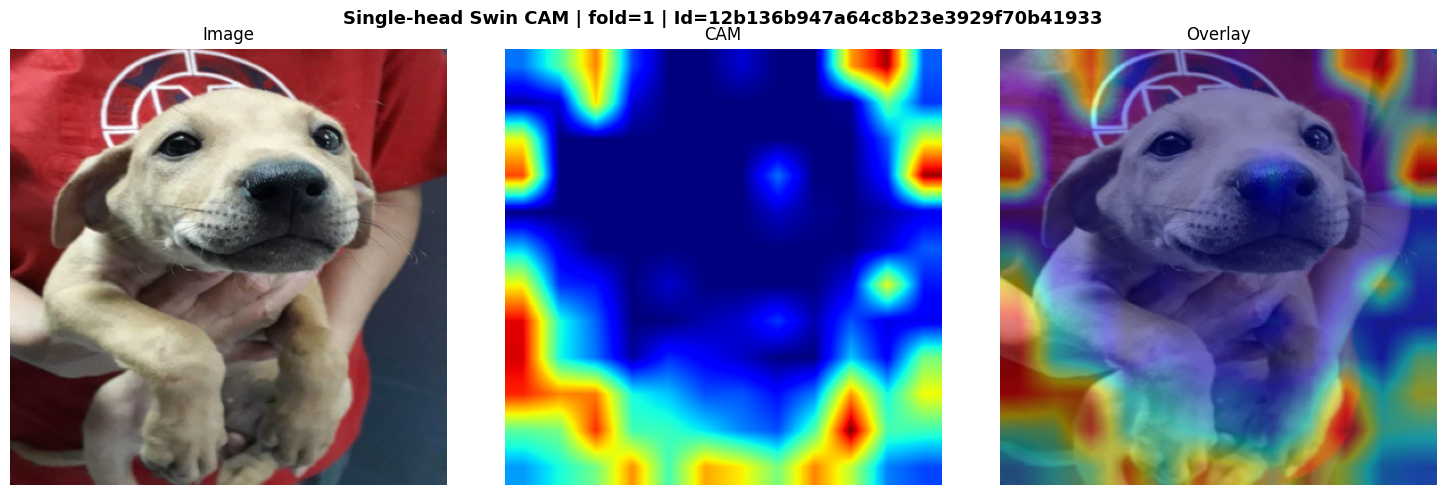

In [8]:
save_dir = os.path.join(out_dir, "cam_examples_single_head")
os.makedirs(save_dir, exist_ok=True)

fig = show_cam_triplet(
    input_tensor=input_tensor,
    cam=cam,
    title=f"Single-head Swin CAM | fold={fold} | Id={img_id}",
    save_path=os.path.join(save_dir, f"{img_id}_fold{fold}_cam.png"),
)
plt.show()

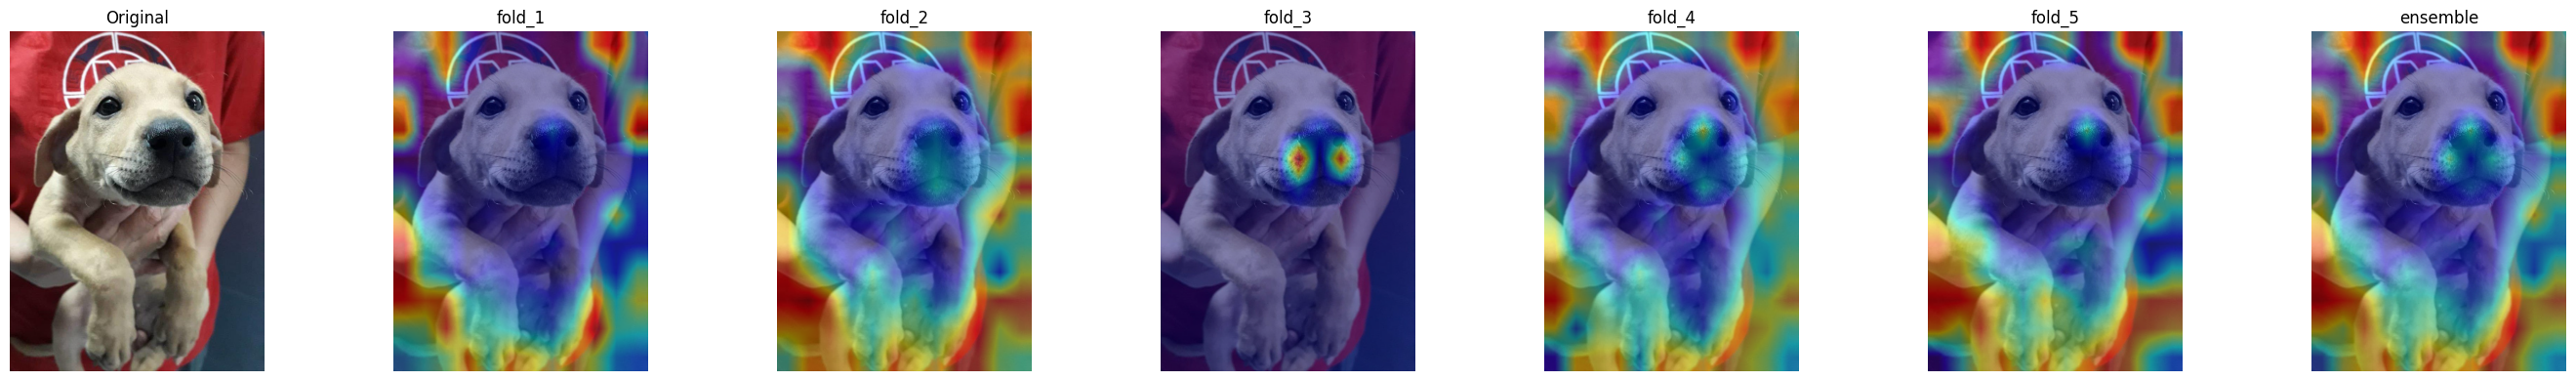

In [9]:
ckpt_paths = [
    os.path.join(out_dir, f"model_fold{i}.pt")
    for i in range(1, 6)
]

cams = ensemble_cam_across_folds(
    img_pil=img_pil,
    ckpt_paths=ckpt_paths,
    backbone_name=backbone_name,
    img_size=img_size,
    aux_tasks=[],
    head_name="main",
    device=device,
)

fig = plot_ensemble_result(
    img_pil=img_pil,
    cams=cams,
    save_path=os.path.join(save_dir, f"{img_id}_ensemble_cam.png"),
)
plt.show()

In [10]:
list(cams.keys())

['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'ensemble']

## Comparison

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

from src.swin_cam import (
    cam_for_single_fold,
    cam_for_single_fold_aux,
    unnormalize_to_numpy,
    overlay_cam_on_image,
)
from src.config import EXP_CONFIGS


def compare_exp3_exp15_on_id(
    img_id: str,
    fold: int,
    main_folder: str = "../..",
    device: str | torch.device = "cuda",
):
    # ---- paths & configs ----
    img_folder = os.path.join(main_folder, "data", "train")

    # exp3 config
    cfg3 = EXP_CONFIGS["exp3"].copy()
    cfg3["img_size"] = 384
    cfg3["loss"] = "mse"
    backbone_name3 = cfg3["backbone"]
    img_size3 = cfg3["img_size"]
    out3 = os.path.join(main_folder, "outputs", "extra", "exp3_swin_384_strong_MSE")
    ckpt3 = os.path.join(out3, f"model_fold{fold}.pt")

    # exp15 config
    cfg15 = EXP_CONFIGS["exp15_aux_brisque"].copy()
    cfg15["img_size"] = 384
    cfg15["loss"] = "mse"
    backbone_name15 = cfg15["backbone"]
    img_size15 = cfg15["img_size"]
    aux_tasks15 = cfg15["aux_tasks"]
    out15 = os.path.join(
        main_folder,
        "outputs",
        "extra",
        "exp15_swin_384_strong_MSE_aux_brisque_normalized",
    )
    ckpt15 = os.path.join(out15, f"model_fold{fold}.pt")

    # ---- load image ----
    img_path = os.path.join(img_folder, img_id + ".jpg")
    img_pil = Image.open(img_path).convert("RGB")

    # ---- exp3 CAM (main only) ----
    cam3, input3, _ = cam_for_single_fold(
        img_pil=img_pil,
        ckpt_path=ckpt3,
        backbone_name=backbone_name3,
        img_size=img_size3,
        device=device,
    )

    # ---- exp15 CAMs (main + brisque) ----
    cam15_main, input15, _ = cam_for_single_fold_aux(
        img_pil=img_pil,
        ckpt_path=ckpt15,
        backbone_name=backbone_name15,
        img_size=img_size15,
        aux_tasks=aux_tasks15,
        head_name="main",
        device=device,
    )

    cam15_bri, _, _ = cam_for_single_fold_aux(
        img_pil=img_pil,
        ckpt_path=ckpt15,
        backbone_name=backbone_name15,
        img_size=img_size15,
        aux_tasks=aux_tasks15,
        head_name="brisque",
        device=device,
    )

    # ---- visualize together ----
    rgb3 = unnormalize_to_numpy(input3)

    ov3 = overlay_cam_on_image(rgb3, cam3)
    ov15_main = overlay_cam_on_image(rgb3, cam15_main)
    ov15_bri = overlay_cam_on_image(rgb3, cam15_bri)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(rgb3)
    axes[0].set_title("Image")
    axes[1].imshow(ov3)
    axes[1].set_title("Exp3 main CAM")
    axes[2].imshow(ov15_main)
    axes[2].set_title("Exp15 main CAM")
    axes[3].imshow(ov15_bri)
    axes[3].set_title("Exp15 BRISQUE CAM")

    for ax in axes:
        ax.axis("off")

    fig.tight_layout()
    return fig

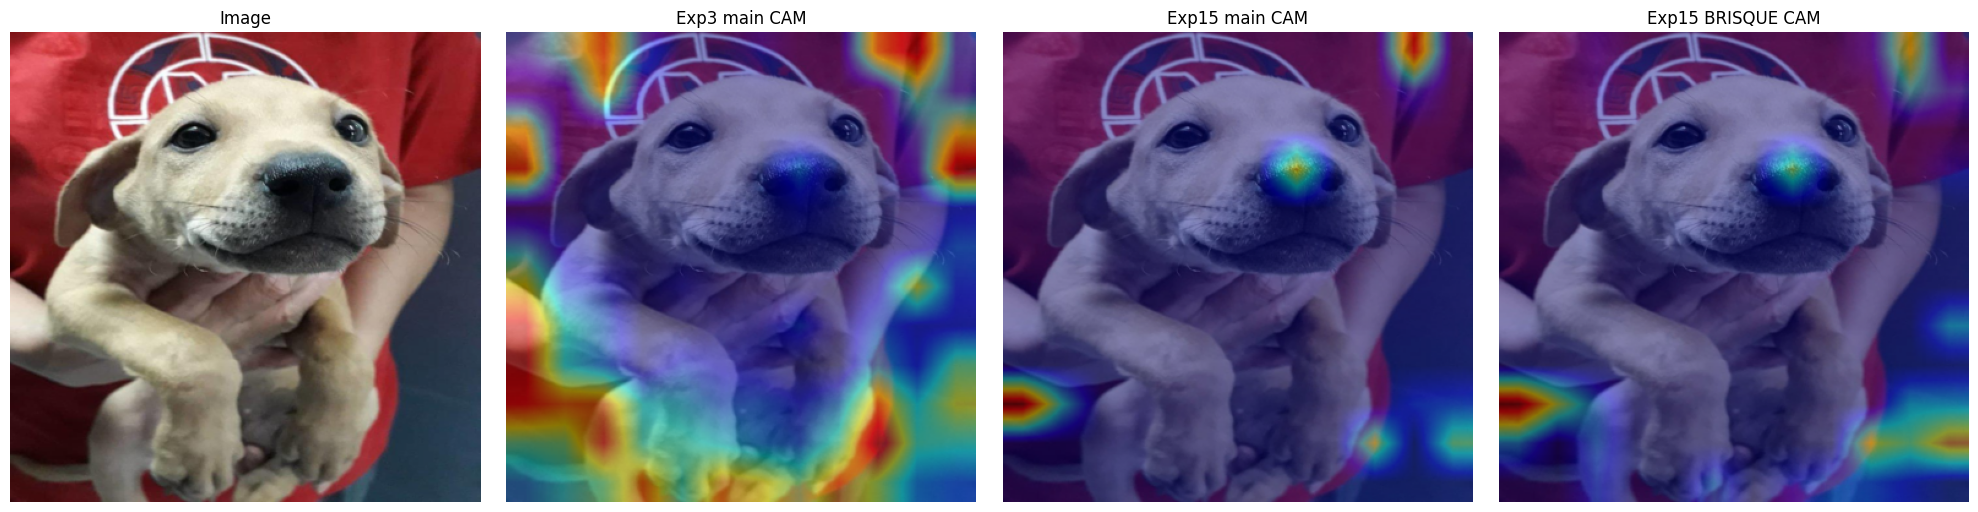

In [14]:
fig = compare_exp3_exp15_on_id(
    img_id=img_id,
    fold=fold,
    main_folder="../..",
    device=device,
)
plt.show()

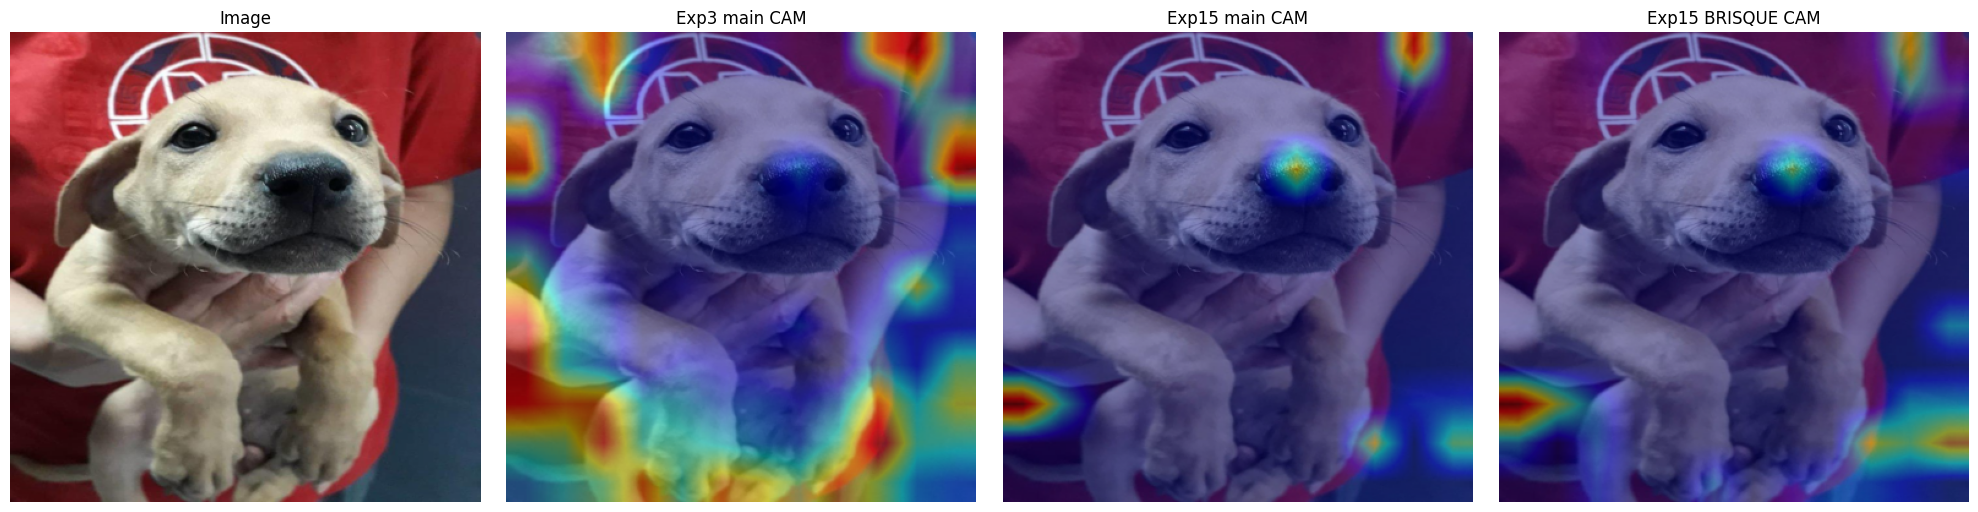

In [17]:
fig = compare_exp3_exp15_on_id(
    img_id=img_id,
    fold=fold,
    main_folder="../..",
    device=device,
)
plt.show()